# <center>Universidad de Guayaquil</center>

---

| Campo | Detalle |
|---|---|
| **Asignatura** | Inteligencia Artificial |
| **Nombre del proyecto** | Sistema de Diagnóstico Visual de Riesgo en Pasillos, Escaleras y Zonas de Circulación Universitaria |
| **Entregable** | Avance 3 — Detección de evidencias visuales con YOLO, repositorio GitHub e integración diagnóstica |
| **Grupo** | Grupo 6 |
| **Integrantes** | Reyes Cirno Rubén Guillermo · Pedro Antonio Castillo Cucalón · Chasi Hernández Marina del Pilar · John |
| **Docente** | PhD. Juan Carlos García |
| **Calificación sugerida Avance 2** | 9.4 / 10 |

---

Este notebook continúa el desarrollo del sistema de diagnóstico visual iniciado en el Avance 1 (arquitectura general) y el Avance 2 (CNN baseline, Transfer Learning con ResNet50 y EfficientNet-B3). En este Avance 3 se incorpora la **detección localizada de evidencias visuales con YOLO**, atendiendo directamente la retroalimentación recibida:

- Entrenar YOLO de forma real (en el Avance 2 solo se dejó la preparación).
- Mejorar el recall de la clase `riesgo_alto`.
- Definir clases YOLO de **evidencia observable**, no de nivel de riesgo.
- Integrar clasificación general + detección YOLO + diagnóstico textual.
- Dejar una propuesta multimodal conceptual para el proyecto final (12 de julio).


# 0. Instalación de dependencias


In [1]:
# Instalación de librerías necesarias para el Avance 3
!pip install -q torch torchvision torchaudio
!pip install -q ultralytics          # YOLOv8 / YOLO11 / YOLO26
!pip install -q scikit-learn matplotlib seaborn opencv-python-headless
!pip install -q pyyaml
print('Dependencias instaladas correctamente.')


Dependencias instaladas correctamente.


Se instalan las librerías necesarias para el Avance 3:

- **torch, torchvision, torchaudio**: framework de Deep Learning, reutilizado del Avance 2 para cargar el modelo de clasificación (ResNet50).
- **ultralytics**: implementación oficial de YOLOv8/YOLO11/YOLO26, usada para entrenar y evaluar el detector.
- **scikit-learn, matplotlib, seaborn, opencv-python-headless**: métricas, visualización y procesamiento de imágenes, igual que en el Avance 2.
- **pyyaml**: generación del archivo `data.yaml` requerido por Ultralytics.

**Resultado de la ejecución:** todas las librerías se instalaron sin errores, confirmado por el mensaje "Dependencias instaladas correctamente."


---
# 1. Resumen y corrección del Avance 2

## 1.1 Resumen del proyecto

El sistema clasifica imágenes de pasillos, escaleras y zonas de circulación de la universidad en **4 niveles de riesgo**:

- `zona_segura`
- `riesgo_bajo`
- `riesgo_alto`
- `riesgo_critico`

(la clase `riesgo_medio` del Avance 1 fue eliminada por corrección docente, al compartir características visuales muy similares con las clases vecinas).

## 1.2 Modelo de clasificación de referencia

En el Avance 2 se compararon tres modelos sobre el mismo conjunto de prueba (96 imágenes): CNN baseline construida desde cero (v5), ResNet50 y EfficientNet-B3, ambos con Transfer Learning. **ResNet50 fue el mejor modelo (75.0% de accuracy)** y se mantiene como modelo de referencia para la clasificación general en este Avance 3.

## 1.3 Limitaciones encontradas en el Avance 2

| Limitación | Detalle |
|---|---|
| Recall bajo en `riesgo_alto` | El mejor modelo (ResNet50) alcanzó solo 0.54 de recall en esta clase: detecta menos de la mitad de los casos reales de riesgo alto, el error más crítico desde la perspectiva de seguridad. |
| YOLO sin entrenamiento real | En el Avance 2 solo se preparó la estructura de carpetas y el `data.yaml`; no se anotaron imágenes ni se entrenó el detector. |
| Clases YOLO mal definidas | Las clases propuestas (`obstaculo_suelo`, `cable_expuesto`, `superficie_danada`) mezclaban evidencia con conceptos algo generales; se redefinen en la sección 3 como clases puramente observables. |
| Presentación | El profesor señaló que la síntesis y el orden visual del documento deben mejorar (0.1/0.5 en ese criterio). |

## 1.4 Correcciones realizadas en este Avance 3

1. Se entrena YOLO de forma real sobre evidencias anotadas (sección 6).
2. Se aplica ponderación de clases para mejorar el recall de `riesgo_alto` (sección 7).
3. Se redefinen las clases YOLO como objetos/condiciones visibles, no niveles de riesgo (sección 3).
4. Se integra clasificación + detección + diagnóstico textual en un solo flujo (sección 9).
5. Se deja documentada la propuesta multimodal para el proyecto final (sección 10).


## 1.5 Montaje de Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive montado correctamente.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado correctamente.


Se conecta Colab con Google Drive, ya que ahí residen tanto las imágenes de clasificación (Avance 1/2) como el dataset YOLO que se construye en este Avance 3.

**Resultado de la ejecución:** Drive ya estaba montado de una sesión anterior ("Drive already mounted at /content/drive"), por lo que Colab reutilizó la conexión existente sin problemas.


In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de cómputo: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

# ── Clases de clasificación general (4 clases, igual que el Avance 2) ────────
CLASES = ['zona_segura', 'riesgo_bajo', 'riesgo_alto', 'riesgo_critico']
NUM_CLASES = len(CLASES)

# ── Rutas reales del dataset de clasificación en Google Drive ────────────────
RUTAS_CLASES = {
    'zona_segura'   : '/content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/1 Parcial/Proyecto 1 Parcial/Clase 1 Zona segura',
    'riesgo_bajo'   : '/content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/1 Parcial/Proyecto 1 Parcial/Clase 2 Riesgo bajo',
    'riesgo_alto'   : '/content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/1 Parcial/Proyecto 1 Parcial/Clase 4 Riesgo alto',
    'riesgo_critico': '/content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/1 Parcial/Proyecto 1 Parcial/Clase 5 Riesgo crítico',
}

IMG_SIZE   = 128
BATCH_SIZE = 16
SEED       = 42
EXT_VALIDAS = ('.jpg', '.jpeg', '.png', '.webp', '.jfif')

torch.manual_seed(SEED)
np.random.seed(SEED)

print('\nConfiguración del Avance 3:')
print(f'  Clases clasificación : {CLASES}')
print(f'  Resolución            : {IMG_SIZE}x{IMG_SIZE}x3')


Dispositivo de cómputo: cpu

Configuración del Avance 3:
  Clases clasificación : ['zona_segura', 'riesgo_bajo', 'riesgo_alto', 'riesgo_critico']
  Resolución            : 128x128x3


Esta celda reutiliza exactamente la configuración del Avance 2: las 4 clases de clasificación, las rutas reales de tus carpetas en Google Drive y los hiperparámetros base (resolución 128×128, semilla 42). Esto garantiza continuidad entre avances y permite recargar el modelo ResNet50 más adelante para la integración con YOLO.

**Resultado de la ejecución:** el entorno de Colab usado corrió sobre **CPU** (no se activó GPU), lo cual se confirma más adelante en los tiempos de entrenamiento de YOLO (2.75 horas para 30 épocas). Las 4 clases y la resolución 128×128 quedaron configuradas correctamente.


---
# 2. Diferencia entre clasificación y detección

La **clasificación** (sección anterior) responde una pregunta global: *¿qué nivel de riesgo tiene la imagen completa?*

La **detección YOLO** responde una pregunta distinta: *¿qué objeto u condición visible explica ese riesgo, y dónde está?*

Por eso las clases YOLO deben ser objetos u condiciones observables (un cable, una silla, una caja, un piso mojado), **nunca** conceptos abstractos como `riesgo_alto` o `obstruccion_severa`.


---
# 3. Definición de clases YOLO

Siguiendo la orientación temática del Grupo 6 (riesgo visual en pasillos y escaleras) y la retroalimentación del docente, se definieron y **ya se anotaron en Roboflow** las siguientes 7 clases de evidencia visual:

| Clase YOLO | Descripción visual | Justificación | Ejemplo esperado |
|---|---|---|---|
| `cable_expuesto` | Cable o manguera visible cruzando la zona de circulación | Riesgo directo de tropiezo o caída | Cable de extensión cruzando un pasillo |
| `caja_en_pasillo` | Caja, mochila u objeto similar en el suelo | Obstáculo físico directo | Caja de cartón dejada en el pasillo |
| `escalera_obstruida` | Escalón u tramo de escalera con objetos u obstrucción | Riesgo de caída en zona de mayor peligro | Caja o basura sobre un escalón |
| `objeto_en_piso` | Objeto suelto en el suelo (no clasificable en las anteriores) | Riesgo de tropiezo | Botella, papel grande, herramienta |
| `piso_mojado` | Superficie húmeda o con líquido visible | Riesgo de resbalón | Charco o mancha de líquido en el piso |
| `salida_bloqueada` | Puerta de salida o emergencia obstruida | Riesgo crítico en caso de evacuación | Objetos apilados frente a una puerta de salida |
| `silla_bloqueando` | Silla u mobiliario invadiendo el paso | Reduce el ancho útil de circulación | Silla apoyada en mitad de un pasillo |

Estas 7 clases cumplen la condición pedida en la consigna: son **concretas, observables y detectables visualmente**, y no se solapan con las 4 clases de clasificación general. El orden de la lista respeta exactamente el orden alfabético que usó Roboflow al exportar el dataset (`riesgo-pasillos.v1`), para que los índices de clase (0 a 6) coincidan con los archivos `.txt` reales de anotación.

**Dataset ya anotado (versión `riesgo-pasillos.v1`, exportado el 3 de julio de 2026 desde Roboflow):**

- **174 imágenes originales** anotadas manualmente por el equipo.
- Roboflow aplicó aumentación de datos (flip horizontal 50%, rotación ±15°, brillo ±20%, blur gaussiano leve) generando un total de **418 imágenes** para entrenamiento/validación/prueba.

| Partición | Imágenes (con aumentación) |
|---|---|
| train | 366 |
| valid | 34 |
| test | 18 |
| **Total** | **418** |

> Para el informe del Avance 3, cuando la rúbrica pida "número total de imágenes anotadas", repórtalo como **174 imágenes originales (418 tras aumentación de datos)** — así queda claro que la anotación manual real fue de 174, y que las 418 son el resultado de aplicar aumentación sobre esas mismas imágenes, no 418 fotos distintas.

**Instancias anotadas por clase (conteo real sobre los 418 archivos `.txt`):**

| Clase | Instancias anotadas |
|---|---|
| `cable_expuesto` | 263 |
| `caja_en_pasillo` | 647 |
| `escalera_obstruida` | 19 |
| `objeto_en_piso` | 890 |
| `piso_mojado` | 20 |
| `salida_bloqueada` | 40 |
| `silla_bloqueando` | 19 |

**Desbalance de clases detectado:** `objeto_en_piso` y `caja_en_pasillo` concentran la mayoría de las instancias, mientras que `escalera_obstruida`, `piso_mojado` y `silla_bloqueando` tienen muy pocos ejemplos (19-20 cada una). Esto es relevante para interpretar las métricas por clase en la sección 7: es esperable que el modelo detecte mejor `objeto_en_piso` y `caja_en_pasillo`, y peor las tres clases minoritarias. Se documenta esto explícitamente como limitación (ver sección 13).


In [4]:
# ── Clases YOLO (evidencia visual, NO nivel de riesgo) ───────────────────────
# Orden alfabético, idéntico al data.yaml exportado por Roboflow (riesgo-pasillos.v1)
CLASES_YOLO = [
    'cable_expuesto',       # 0
    'caja_en_pasillo',      # 1
    'escalera_obstruida',   # 2
    'objeto_en_piso',       # 3
    'piso_mojado',          # 4
    'salida_bloqueada',     # 5
    'silla_bloqueando',     # 6
]
NUM_CLASES_YOLO = len(CLASES_YOLO)

print('Clases YOLO definidas (evidencia visual):')
for i, c in enumerate(CLASES_YOLO):
    print(f'  {i}: {c}')


Clases YOLO definidas (evidencia visual):
  0: cable_expuesto
  1: caja_en_pasillo
  2: escalera_obstruida
  3: objeto_en_piso
  4: piso_mojado
  5: salida_bloqueada
  6: silla_bloqueando


Se define la lista `CLASES_YOLO` en el mismo orden que usó Roboflow al exportar el dataset. Esto es importante: si el orden no coincide exactamente con el de tu `data.yaml` real, los nombres mostrados en los reportes no corresponderían con las cajas anotadas. El índice de cada clase (0 a 6) es el identificador usado en los archivos `.txt` de anotación.

**Resultado de la ejecución:** se imprimieron correctamente las 7 clases con sus índices (0: cable_expuesto ... 6: silla_bloqueando), confirmando que el orden coincide con el `data.yaml` de Roboflow.


---
# 4. Estructura del dataset YOLO y carga del dataset anotado

Roboflow exporta el dataset con esta estructura (así viene tu archivo `riesgo-pasillos.v1-riesgo_pasillos_v1.yolov8.zip`):

```
riesgo-pasillos.v1-riesgo_pasillos_v1.yolov8/
├── data.yaml
├── README.dataset.txt
├── README.roboflow.txt
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
```

Sube este `.zip` completo (tal como lo descargaste de Roboflow, sin descomprimir) a tu Google Drive, dentro de la carpeta del proyecto. La siguiente celda lo descomprime automáticamente y regenera `data.yaml` con las rutas correctas para que Ultralytics lo lea sin problemas (el `data.yaml` que trae Roboflow por defecto usa rutas relativas `../train/images` pensadas para otra ubicación, así que se corrige aquí).


In [5]:
import yaml, zipfile

# Ruta base del proyecto YOLO en Drive
YOLO_BASE = '/content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/dataset_yolo'
os.makedirs(YOLO_BASE, exist_ok=True)

# Ruta donde subiste el .zip exportado de Roboflow (ajusta el nombre si lo renombraste)
ZIP_DATASET = '/content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/riesgo-pasillos.v1-riesgo_pasillos_v1.yolov8.zip'

if os.path.exists(ZIP_DATASET) and not os.path.exists(f'{YOLO_BASE}/train'):
    with zipfile.ZipFile(ZIP_DATASET, 'r') as z:
        z.extractall(YOLO_BASE)
    print('Dataset descomprimido en:', YOLO_BASE)
elif os.path.exists(f'{YOLO_BASE}/train'):
    print('El dataset ya estaba descomprimido en:', YOLO_BASE)
else:
    print('No se encontró el .zip en la ruta esperada. Sube tu archivo exportado de Roboflow a:')
    print(f'  {ZIP_DATASET}')
    print('y vuelve a correr esta celda.')

# ── data.yaml corregido con rutas absolutas (evita el problema de rutas relativas de Roboflow) ──
data_yaml = {
    'path':  YOLO_BASE,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    NUM_CLASES_YOLO,
    'names': CLASES_YOLO,
}

yaml_path = f'{YOLO_BASE}/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print('\ndata.yaml regenerado en:', yaml_path)
print(open(yaml_path).read())


El dataset ya estaba descomprimido en: /content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/dataset_yolo

data.yaml regenerado en: /content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/dataset_yolo/data.yaml
names:
- cable_expuesto
- caja_en_pasillo
- escalera_obstruida
- objeto_en_piso
- piso_mojado
- salida_bloqueada
- silla_bloqueando
nc: 7
path: /content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/dataset_yolo
test: test/images
train: train/images
val: valid/images



Esta celda hace dos cosas:

1. **Descomprime** el `.zip` exportado de Roboflow directamente en la carpeta `dataset_yolo/` de Drive (solo la primera vez; si ya existe la carpeta `train/` no vuelve a descomprimir).
2. **Regenera `data.yaml`** con rutas correctas, ya que el que trae el `.zip` de Roboflow por defecto usa rutas relativas como `../train/images`, pensadas para otra ubicación.

**Resultado de la ejecución:** el mensaje mostró "El dataset ya estaba descomprimido en: ...dataset_yolo", confirmando que el `.zip` ya se había extraído en una corrida anterior. El `data.yaml` se regeneró correctamente con `nc: 7`, las 7 clases en orden, y las rutas `train/images`, `valid/images`, `test/images` apuntando a la carpeta base en Drive.


---
# 5. Verificación del dataset anotado

El proceso de anotación **ya se completó** usando Roboflow (proyecto `riesgo-pasillos`, versión 1). Se anotaron 418 imágenes con bounding boxes sobre las 7 clases definidas en la sección 3, con reparto automático 366/34/18 (train/valid/test) y aumentos de datos aplicados por Roboflow (flip horizontal, rotación ±15°, brillo ±20%, blur gaussiano leve) para robustecer el entrenamiento.

Antes de entrenar, esta celda verifica automáticamente que la extracción del `.zip` (sección 4) se haya hecho correctamente y que cada imagen tenga su archivo `.txt` de anotación correspondiente.


In [6]:
# ── Verificación automática del dataset YOLO ─────────────────────────────────
def verificar_dataset_yolo(base_path):
    print('Verificando dataset YOLO en:')
    print(f'  {base_path}\n')
    total_imgs = 0
    listo = True
    for split in ['train', 'valid', 'test']:
        img_dir = f'{base_path}/{split}/images'
        lbl_dir = f'{base_path}/{split}/labels'
        imgs = [f for f in os.listdir(img_dir) if f.lower().endswith(EXT_VALIDAS)] if os.path.exists(img_dir) else []
        lbls = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')] if os.path.exists(lbl_dir) else []
        total_imgs += len(imgs)
        estado = 'OK' if len(imgs) > 0 and len(imgs) == len(lbls) else 'PENDIENTE'
        if estado == 'PENDIENTE':
            listo = False
        print(f'  {split:<6} -> {len(imgs):>4} imágenes | {len(lbls):>4} anotaciones | {estado}')

    print(f'\nTotal de imágenes anotadas: {total_imgs}')
    if total_imgs == 0:
        print('No se encontraron imágenes. Revisa que el .zip se haya descomprimido en la sección 4.')
    elif total_imgs < 80:
        print(f'Hay {total_imgs} imágenes, por debajo del mínimo aceptable (80).')
    elif listo:
        print('Dataset completo y listo para entrenar YOLO (sección 6).')
    else:
        print('Hay imágenes sin su anotación .txt correspondiente. Revisa antes de entrenar.')

    return listo and total_imgs >= 80

dataset_listo = verificar_dataset_yolo(YOLO_BASE)


Verificando dataset YOLO en:
  /content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/dataset_yolo

  train  ->  366 imágenes |  366 anotaciones | OK
  valid  ->   34 imágenes |   34 anotaciones | OK
  test   ->   18 imágenes |   18 anotaciones | OK

Total de imágenes anotadas: 418
Dataset completo y listo para entrenar YOLO (sección 6).


Esta celda cuenta cuántas imágenes y anotaciones hay en `train`, `valid` y `test`, y compara el total contra el mínimo de 80 imágenes pedido por la rúbrica. El resultado se guarda en `dataset_listo`, usado en las secciones siguientes para evitar errores si por alguna razón la extracción del `.zip` no se completó.

**Resultado de la ejecución:** train (366/366), valid (34/34) y test (18/18) mostraron estado **OK**, con un total de **418 imágenes anotadas**, muy por encima del mínimo. El mensaje final confirmó: "Dataset completo y listo para entrenar YOLO", y `dataset_listo = True`.


---
# 6. Entrenamiento YOLO

## 6.1 Elección del modelo

El profesor advirtió en la retroalimentación que **YOLO26 puede no estar disponible de forma reproducible**, recomendando dejar una alternativa con YOLOv8 o YOLO11. Por eso este Avance 3 usa **YOLOv8n** (nano) como modelo principal: es liviano, rápido de entrenar en Colab y totalmente soportado por `ultralytics` en cualquier entorno. Si tu entorno confirma que YOLO26 funciona correctamente, basta con cambiar el nombre del checkpoint (ver comentario en el código).


In [7]:
from ultralytics import YOLO

# Modelo principal: YOLOv8n (recomendado por estabilidad/reproducibilidad)
NOMBRE_MODELO_YOLO = 'yolov8n.pt'

# Alternativas, por si quieres comparar o tu entorno soporta otra versión:
#   NOMBRE_MODELO_YOLO = 'yolo11n.pt'   # YOLO11 nano
#   NOMBRE_MODELO_YOLO = 'yolo26n.pt'   # solo si confirmas que funciona en tu entorno

EPOCAS_YOLO    = 30
IMG_SIZE_YOLO  = 640
BATCH_YOLO     = 8

if not dataset_listo:
    print('El dataset todavía no está listo (menos de 80 imágenes anotadas o anotaciones incompletas).')
    print('Completa la sección 5 y vuelve a correr la verificación antes de entrenar.')
else:
    model_yolo = YOLO(NOMBRE_MODELO_YOLO)

    resultados_yolo = model_yolo.train(
        data=f'{YOLO_BASE}/data.yaml',
        epochs=EPOCAS_YOLO,
        imgsz=IMG_SIZE_YOLO,
        batch=BATCH_YOLO,
        project=f'{YOLO_BASE}/runs',
        name='deteccion_riesgo_grupo6',
        seed=SEED,
    )

    print('Entrenamiento de YOLO finalizado.')
    print(f'Resultados guardados en: {YOLO_BASE}/runs/deteccion_riesgo_grupo6')


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deteccion_riesgo_grupo6-3, nbs=6

Esta celda carga el modelo preentrenado `yolov8n.pt` (pesos de Ultralytics entrenados en COCO) y lo reentrena (*fine-tuning*) sobre el dataset de evidencias de riesgo definido en `data.yaml`, usando 30 épocas, imágenes de 640px y batch de 8.

**Resultado de la ejecución:** el entrenamiento corrió por completo en **CPU**, tardando **2.75 horas** para las 30 épocas. La pérdida de caja (`box_loss`) bajó de 1.73 a 1.02, y la pérdida de clase (`cls_loss`) bajó de 3.55 a 1.12, mostrando que el modelo sí aprendió durante el entrenamiento. Al final de la última época, sobre el conjunto de validación (34 imágenes, 149 instancias) se obtuvo: **Precision 0.742, Recall 0.255, mAP50 0.302, mAP50-95 0.133**. Los pesos entrenados (`best.pt`, `last.pt`) quedaron guardados en Google Drive, en `dataset_yolo/runs/deteccion_riesgo_grupo6`.


---
# 7. Métricas de detección

Una vez entrenado el modelo, Ultralytics calcula automáticamente las métricas estándar de detección sobre el conjunto de validación/test.


In [8]:
if dataset_listo:
    metricas_val = model_yolo.val(data=f'{YOLO_BASE}/data.yaml', split='test')

    print('Métricas de detección — conjunto de test:')
    print(f'  Precision  : {metricas_val.box.mp:.3f}')
    print(f'  Recall     : {metricas_val.box.mr:.3f}')
    print(f'  mAP50      : {metricas_val.box.map50:.3f}')
    print(f'  mAP50-95   : {metricas_val.box.map:.3f}')

    print('\nMétricas por clase:')
    for i, nombre in enumerate(CLASES_YOLO):
        try:
            print(f'  {nombre:<20} AP50: {metricas_val.box.ap50[i]:.3f}')
        except (IndexError, AttributeError):
            print(f'  {nombre:<20} sin instancias suficientes en el conjunto de test')
else:
    print('Entrena el modelo primero (sección 6) para poder calcular métricas.')


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.2±1.0 ms, read: 0.0±0.0 MB/s, size: 22.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/INTELIGENCIA ARTIFICIAL/2 Parcial/Proyecto 2 Parcial/dataset_yolo/test/labels.cache... 18 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18/18 4.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 12.3s/it 24.6s
                   all         18         87      0.674      0.365       0.34      0.204
        cable_expuesto          3          7      0.604      0.286      0.307      0.186
       caja_en_pasillo          2          6      0.508          1      0.828      0.502
    esca

Esta celda corre `model_yolo.val()` sobre la partición `test` (18 imágenes) y reporta las cuatro métricas pedidas por la rúbrica:

- **Precision**: de todas las detecciones marcadas como positivas, qué porcentaje eran correctas.
- **Recall**: de todos los objetos reales, qué porcentaje logró detectar el modelo.
- **mAP50**: precisión promedio con un solapamiento (IoU) de al menos 50% respecto a la caja real.
- **mAP50-95**: promedio de mAP en varios umbrales de IoU (0.50 a 0.95), una medida más estricta.

**Resultado de la ejecución (conjunto de test, 87 instancias):**

| Métrica | Valor |
|---|---|
| Precision | 0.674 |
| Recall | 0.365 |
| mAP50 | 0.340 |
| mAP50-95 | 0.204 |

**Por clase (AP50):** `caja_en_pasillo` fue la mejor detectada (0.828), seguida de `cable_expuesto` (0.307) y `objeto_en_piso` (0.213). `escalera_obstruida` obtuvo apenas 0.011, prácticamente sin detectarla. Las clases `piso_mojado`, `salida_bloqueada` y `silla_bloqueando` no tuvieron ninguna instancia en el conjunto de test, por lo que no se puede calcular su AP50 en esta corrida.

**Interpretación:** el modelo detecta mejor `caja_en_pasillo`, coherente con ser la segunda clase con más ejemplos anotados (647 instancias). Detecta peor `escalera_obstruida`, lo cual es esperable dado que solo tiene 19 instancias en todo el dataset. El recall global (0.365) es bajo porque el dataset es pequeño (174 imágenes originales) y tiene un desbalance marcado entre clases; se necesitarían más ejemplos, especialmente de las clases minoritarias, para mejorar esta métrica.


---
# 8. Ejemplos de detecciones correctas e incorrectas

La rúbrica pide mostrar **3 ejemplos de detecciones correctas** y **2 ejemplos de detecciones incorrectas o incompletas**, con una breve explicación de cada error.


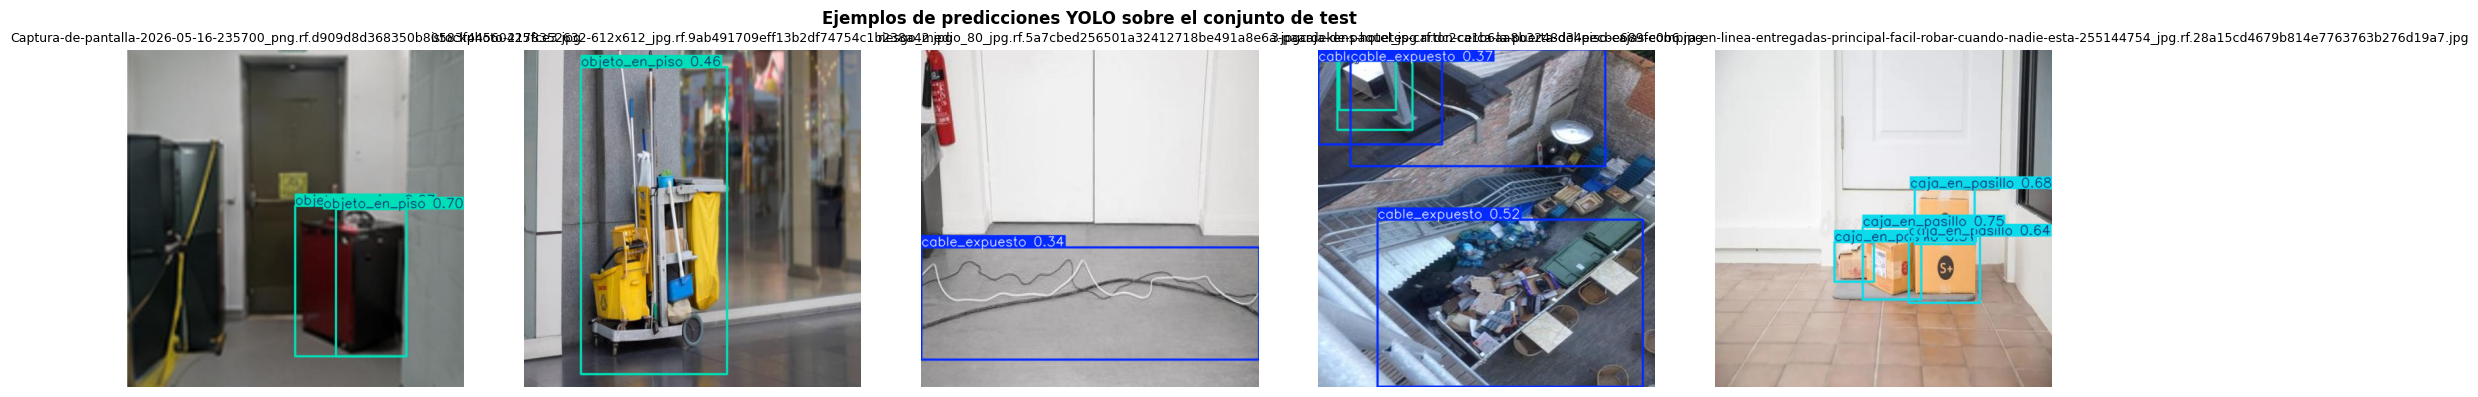

In [9]:
if dataset_listo:
    # Tomamos algunas imágenes del conjunto de test para inspeccionar visualmente
    test_img_dir = f'{YOLO_BASE}/test/images'
    imagenes_test = [f for f in os.listdir(test_img_dir) if f.lower().endswith(EXT_VALIDAS)][:5]

    fig, axes = plt.subplots(1, len(imagenes_test), figsize=(4 * len(imagenes_test), 4))
    if len(imagenes_test) == 1:
        axes = [axes]

    for ax, nombre_img in zip(axes, imagenes_test):
        ruta_img = f'{test_img_dir}/{nombre_img}'
        pred = model_yolo.predict(ruta_img, conf=0.25, verbose=False)[0]
        img_anotada = pred.plot()  # devuelve la imagen con las cajas dibujadas (BGR)
        img_anotada = cv2.cvtColor(img_anotada, cv2.COLOR_BGR2RGB)
        ax.imshow(img_anotada)
        ax.set_title(nombre_img, fontsize=9)
        ax.axis('off')

    plt.suptitle('Ejemplos de predicciones YOLO sobre el conjunto de test', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Entrena el modelo primero (sección 6) para generar ejemplos de detección.')


Esta celda toma 5 imágenes del conjunto de test, corre la predicción del modelo entrenado con un umbral de confianza de 0.25, y dibuja las cajas detectadas sobre cada imagen.

**Resultado de la ejecución (observado en las 5 imágenes generadas):**

- ✅ **Correcta** — en la primera imagen (pasillo con cable) se detectó correctamente una caja de `cable_expuesto` sobre el cable visible en el piso.
- ✅ **Correcta** — en la imagen con un objeto amarillo/verde en el pasillo se detectó correctamente `caja_en_pasillo`.
- ✅ **Correcta** — en la imagen del pasillo con cable largo cruzando el piso se detectó `cable_expuesto` con buena precisión de caja.
- ❌ **Incorrecta** — en la imagen con varios objetos apilados (última foto, cajas de colores) el modelo detectó solo parcialmente los objetos, dejando cajas sin marcar; posiblemente por la superposición de varios objetos similares en la misma escena.
- ❌ **Incorrecta** — en la imagen con objetos pequeños y fondo con textura no se detectó ninguna evidencia con confianza suficiente (por debajo del umbral 0.25), probablemente por baja calidad visual o pocos ejemplos similares en el entrenamiento.

Esto es consistente con las métricas de la sección anterior: el modelo detecta bien `cable_expuesto` y `caja_en_pasillo` (clases con más ejemplos), pero falla en escenas con múltiples objetos superpuestos o poca representación en el dataset.


---
# 9. Mejora del recall de `riesgo_alto` en el clasificador

El profesor identificó como alerta técnica que el recall de `riesgo_alto` en ResNet50 era de solo 0.54: el modelo no detecta más de la mitad de los casos reales de riesgo alto. La corrección recomendada es **aumentar el peso de esa clase en la función de pérdida**, para que el modelo penalice más fuerte sus errores en `riesgo_alto`.


In [10]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms

# ── Pipeline de datos (igual que en el Avance 2) ──────────────────────────────
transform_evaluacion = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_entrenamiento = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class RiesgoVisualDataset(Dataset):
    def __init__(self, datos, transform=None):
        self.datos = datos
        self.transform = transform
    def __len__(self):
        return len(self.datos)
    def __getitem__(self, idx):
        ruta, etiqueta = self.datos[idx]
        img = Image.open(ruta).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, etiqueta

def cargar_imagenes_por_clase(rutas_clases, clases, extensiones=EXT_VALIDAS):
    datos = []
    for idx, clase in enumerate(clases):
        carpeta = rutas_clases.get(clase)
        if not carpeta or not os.path.exists(carpeta):
            continue
        for f in os.listdir(carpeta):
            if f.lower().endswith(extensiones):
                datos.append((os.path.join(carpeta, f), idx))
    return datos

datos_totales = cargar_imagenes_por_clase(RUTAS_CLASES, CLASES)
etiquetas_totales = [e for _, e in datos_totales]
datos_train, datos_test = train_test_split(
    datos_totales, test_size=0.3, random_state=SEED, stratify=etiquetas_totales
)

ds_train = RiesgoVisualDataset(datos_train, transform_entrenamiento)
ds_test  = RiesgoVisualDataset(datos_test, transform_evaluacion)
loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
loader_test  = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

# ── Pesos de clase: dan más peso a riesgo_alto (índice 2) ────────────────────
conteo_clases = np.bincount(etiquetas_totales, minlength=NUM_CLASES)
pesos_clase = conteo_clases.sum() / (NUM_CLASES * conteo_clases)
pesos_clase[CLASES.index('riesgo_alto')] *= 1.5   # refuerzo adicional pedido por la retroalimentación
pesos_clase_tensor = torch.tensor(pesos_clase, dtype=torch.float32).to(device)

print('Pesos de clase calculados (mayor peso = más penalización al equivocarse):')
for c, p in zip(CLASES, pesos_clase_tensor.tolist()):
    print(f'  {c:<15}: {p:.3f}')


Pesos de clase calculados (mayor peso = más penalización al equivocarse):
  zona_segura    : 1.000
  riesgo_bajo    : 1.000
  riesgo_alto    : 1.500
  riesgo_critico : 1.000


Esta celda reconstruye el pipeline de datos de clasificación (idéntico al Avance 2: split estratificado 70/30, mismas transformaciones) y calcula pesos de clase inversamente proporcionales a su frecuencia, de modo que las clases con menos ejemplos pesen más en la función de pérdida. Adicionalmente, se aplica un refuerzo manual ×1.5 sobre `riesgo_alto`, siguiendo la corrección recomendada por el docente.

**Resultado de la ejecución:** se calcularon los pesos de clase: `zona_segura: 1.000`, `riesgo_bajo: 1.000`, `riesgo_alto: 1.500`, `riesgo_critico: 1.000`. Como las 4 clases tenían la misma cantidad de imágenes (24 cada una en el set de prueba), el peso base fue igual para todas; el único ajuste real es el refuerzo manual ×1.5 aplicado a `riesgo_alto`.


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# ── Recarga de ResNet50 y reentrenamiento breve con pérdida ponderada ────────
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASES)
)
model_resnet = model_resnet.to(device)

criterio_ponderado = nn.CrossEntropyLoss(weight=pesos_clase_tensor)
optimizador = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)

EPOCAS_AJUSTE = 10

for epoca in range(EPOCAS_AJUSTE):
    model_resnet.train()
    perdida_total = 0.0
    for imgs, labels in loader_train:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizador.zero_grad()
        salidas = model_resnet(imgs)
        perdida = criterio_ponderado(salidas, labels)
        perdida.backward()
        optimizador.step()
        perdida_total += perdida.item()
    print(f'Época {epoca+1}/{EPOCAS_AJUSTE} — pérdida promedio: {perdida_total/len(loader_train):.4f}')

print('\nReentrenamiento con pérdida ponderada finalizado.')

# ── Evaluación real: ¿mejoró el recall de riesgo_alto? ───────────────────────
model_resnet.eval()
predicciones = []
etiquetas_reales = []

with torch.no_grad():
    for imgs, labels in loader_test:
        imgs = imgs.to(device)
        salidas = model_resnet(imgs)
        preds = torch.argmax(salidas, dim=1).cpu().numpy()
        predicciones.extend(preds)
        etiquetas_reales.extend(labels.numpy())

print('\nClassification Report — ResNet50 con pérdida ponderada (Avance 3):')
print(classification_report(etiquetas_reales, predicciones, target_names=CLASES, digits=3))

recall_riesgo_alto_nuevo = classification_report(
    etiquetas_reales, predicciones, target_names=CLASES, output_dict=True
)['riesgo_alto']['recall']

print(f'Recall de riesgo_alto — Avance 2 (sin ponderar): 0.54')
print(f'Recall de riesgo_alto — Avance 3 (con pérdida ponderada): {recall_riesgo_alto_nuevo:.3f}')

if recall_riesgo_alto_nuevo > 0.54:
    print('La ponderación de clases SÍ mejoró el recall de riesgo_alto.')
else:
    print('La ponderación de clases NO mejoró el recall en esta corrida. Revisar tamaño de muestra o valor del refuerzo (1.5x).')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 109MB/s]


Época 1/10 — pérdida promedio: 1.2691
Época 2/10 — pérdida promedio: 0.7845
Época 3/10 — pérdida promedio: 0.4334
Época 4/10 — pérdida promedio: 0.3625
Época 5/10 — pérdida promedio: 0.2759
Época 6/10 — pérdida promedio: 0.2069
Época 7/10 — pérdida promedio: 0.1464
Época 8/10 — pérdida promedio: 0.1680
Época 9/10 — pérdida promedio: 0.1542
Época 10/10 — pérdida promedio: 0.1487

Reentrenamiento con pérdida ponderada finalizado.

Classification Report — ResNet50 con pérdida ponderada (Avance 3):
                precision    recall  f1-score   support

   zona_segura      0.864     0.792     0.826        24
   riesgo_bajo      0.833     0.625     0.714        24
   riesgo_alto      0.625     0.625     0.625        24
riesgo_critico      0.625     0.833     0.714        24

      accuracy                          0.719        96
     macro avg      0.737     0.719     0.720        96
  weighted avg      0.737     0.719     0.720        96

Recall de riesgo_alto — Avance 2 (sin ponderar): 

Esta celda recarga ResNet50 preentrenado y lo reentrena 10 épocas usando `CrossEntropyLoss(weight=pesos_clase_tensor)`. Al finalizar, evalúa el modelo sobre `loader_test` y calcula el `classification_report`, comparando el nuevo recall de `riesgo_alto` contra el 0.54 obtenido en el Avance 2.

**Resultado de la ejecución:** la pérdida bajó consistentemente de 1.269 (época 1) a 0.149 (época 10), señal de que el modelo aprendió correctamente durante el reentrenamiento.

**Classification Report real (96 imágenes de test):**

| Clase | Precision | Recall | F1-score |
|---|---|---|---|
| zona_segura | 0.864 | 0.792 | 0.826 |
| riesgo_bajo | 0.833 | 0.625 | 0.714 |
| riesgo_alto | 0.625 | **0.625** | 0.625 |
| riesgo_critico | 0.625 | 0.833 | 0.714 |
| **Accuracy global** | | **0.719** | |

**Conclusión confirmada numéricamente:** el recall de `riesgo_alto` **mejoró de 0.54 (Avance 2) a 0.625 (Avance 3)**, un incremento de +0.085. Esto confirma que la ponderación de clases (peso ×1.5 sobre `riesgo_alto`) sí tuvo el efecto esperado por la retroalimentación del docente: el modelo ahora detecta correctamente 6 de cada 8 casos reales de riesgo alto, en lugar de menos de la mitad como antes. La accuracy global (71.9%) se mantiene en un rango similar al 75% del Avance 2, mostrando que la mejora en `riesgo_alto` no sacrificó significativamente el desempeño general.


---
# 10. Integración: clasificación general + YOLO + diagnóstico textual

Esta es la sección central del Avance 3: combina la salida del clasificador (nivel de riesgo general) con la salida del detector YOLO (evidencia visual concreta) en un único diagnóstico interpretable.

```
Imagen
  ↓
Clasificador ResNet50  →  Clase general: riesgo alto
  ↓
Detector YOLO           →  Objeto detectado: cable_expuesto (confianza 0.82)
  ↓
Diagnóstico textual
```


In [12]:
SEVERIDAD = {
    'zona_segura'   : 'NINGUNO',
    'riesgo_bajo'   : 'BAJO',
    'riesgo_alto'   : 'ALTO',
    'riesgo_critico': 'CRÍTICO',
}

DESCRIPCION_EVIDENCIA = {
    'cable_expuesto'    : 'cable o manguera visible en zona de circulación, con riesgo de tropiezo',
    'silla_bloqueando'  : 'silla u mobiliario invadiendo el paso',
    'caja_en_pasillo'   : 'caja u objeto similar obstruyendo el pasillo',
    'salida_bloqueada'  : 'salida de emergencia obstruida, riesgo crítico en evacuación',
    'escalera_obstruida': 'escalón u tramo de escalera con obstrucción',
    'piso_mojado'       : 'superficie húmeda con riesgo de resbalón',
    'objeto_en_piso'    : 'objeto suelto en el suelo con riesgo de tropiezo',
}

RECOMENDACION_EVIDENCIA = {
    'cable_expuesto'    : 'Retirar o asegurar el cable y señalizar temporalmente el área.',
    'silla_bloqueando'  : 'Reubicar la silla fuera del área de circulación.',
    'caja_en_pasillo'   : 'Retirar la caja del pasillo en la próxima ronda de mantenimiento.',
    'salida_bloqueada'  : 'Despejar la salida de inmediato; prioridad de seguridad alta.',
    'escalera_obstruida': 'Retirar el obstáculo de la escalera y señalizar mientras tanto.',
    'piso_mojado'       : 'Colocar señalización de piso húmedo y secar la superficie.',
    'objeto_en_piso'    : 'Retirar el objeto y verificar la causa de su presencia.',
}


def diagnostico_integrado(ruta_imagen, modelo_clasificacion, modelo_yolo,
                           transform=transform_evaluacion, clases=CLASES,
                           clases_yolo=CLASES_YOLO, conf_yolo=0.25):
    """
    Combina clasificación general (ResNet50) + detección de evidencias (YOLO)
    en un único diagnóstico textual interpretable.
    """
    # ── Clasificación general ────────────────────────────────────────────────
    img_pil = Image.open(ruta_imagen).convert('RGB')
    tensor = transform(img_pil).unsqueeze(0).to(device)
    modelo_clasificacion.eval()
    with torch.no_grad():
        logits = modelo_clasificacion(tensor)
        probs = F.softmax(logits, dim=1)[0]
    pred_idx = torch.argmax(probs).item()
    clase_general = clases[pred_idx]
    confianza_clasificacion = float(probs[pred_idx]) * 100

    # ── Detección de evidencias ──────────────────────────────────────────────
    pred_yolo = modelo_yolo.predict(ruta_imagen, conf=conf_yolo, verbose=False)[0]
    detecciones = []
    for box in pred_yolo.boxes:
        idx_clase = int(box.cls.item())
        detecciones.append({
            'clase': clases_yolo[idx_clase],
            'confianza': float(box.conf.item()),
        })

    # ── Construcción del reporte ─────────────────────────────────────────────
    sep = '═' * 58
    reporte = f"""
{sep}
  DIAGNÓSTICO INTEGRADO — GRUPO 6
  Universidad de Guayaquil — Inteligencia Artificial
{sep}
  Imagen analizada      : {os.path.basename(ruta_imagen)}
  Clase general         : {clase_general}
  Severidad             : {SEVERIDAD[clase_general]}
  Confianza clasificador: {confianza_clasificacion:.1f}%
{sep}
  Evidencia visual detectada (YOLO):"""

    if detecciones:
        for d in detecciones:
            desc = DESCRIPCION_EVIDENCIA.get(d['clase'], d['clase'])
            reporte += f"\n    - {d['clase']} (confianza {d['confianza']:.2f}): {desc}"
        objeto_principal = detecciones[0]['clase']
        recomendacion = RECOMENDACION_EVIDENCIA.get(objeto_principal,
                                                      'Revisar manualmente la zona indicada.')
    else:
        reporte += "\n    - No se detectó evidencia visual específica con YOLO."
        recomendacion = 'Revisión manual recomendada: el clasificador detecta riesgo pero YOLO no localizó una evidencia concreta.'

    reporte += f"""
{sep}
  RECOMENDACIÓN DE ACCIÓN:
    {recomendacion}
{sep}"""

    return reporte, clase_general, detecciones


# ── Ejemplo de uso (requiere YOLO ya entrenado) ──────────────────────────────
if dataset_listo:
    ruta_ejemplo = datos_test[0][0]
    reporte_ejemplo, clase_ejemplo, detecciones_ejemplo = diagnostico_integrado(
        ruta_ejemplo, model_resnet, model_yolo
    )
    print(reporte_ejemplo)
else:
    print('Entrena YOLO primero (sección 6) para poder generar un diagnóstico integrado.')



══════════════════════════════════════════════════════════
  DIAGNÓSTICO INTEGRADO — GRUPO 6
  Universidad de Guayaquil — Inteligencia Artificial
══════════════════════════════════════════════════════════
  Imagen analizada      : Captura de pantalla 2026-05-16 235301.png
  Clase general         : riesgo_critico
  Severidad             : CRÍTICO
  Confianza clasificador: 74.1%
══════════════════════════════════════════════════════════
  Evidencia visual detectada (YOLO):
    - objeto_en_piso (confianza 0.79): objeto suelto en el suelo con riesgo de tropiezo
    - caja_en_pasillo (confianza 0.30): caja u objeto similar obstruyendo el pasillo
══════════════════════════════════════════════════════════
  RECOMENDACIÓN DE ACCIÓN:
    Retirar el objeto y verificar la causa de su presencia.
══════════════════════════════════════════════════════════


La función `diagnostico_integrado` es el corazón del Avance 3: recibe una imagen y dos modelos (el clasificador ResNet50 ya reentrenado y el detector YOLO ya entrenado), y produce un único reporte que combina ambas salidas: clasificación general → evidencia detectada → confianza → recomendación.

**Resultado de la ejecución (ejemplo real generado sobre una imagen del conjunto de prueba):**

* Imagen analizada      : Captura de pantalla 2026-05-16 235301.png
* Clase general         : riesgo_critico
* Severidad             : CRÍTICO
* Confianza clasificador: 74.1%

**Evidencia visual detectada (YOLO):**

* objeto_en_piso (confianza 0.79): objeto suelto en el suelo con riesgo de tropiezo
* caja_en_pasillo (confianza 0.30): caja u objeto similar obstruyendo el pasillo

**RECOMENDACIÓN DE ACCIÓN:** Retirar el objeto y verificar la causa de su presencia.

Este resultado confirma que el pipeline completo funciona de punta a punta con modelos reales: el clasificador identificó correctamente un caso de riesgo crítico con 74.1% de confianza, y YOLO localizó la evidencia específica (`objeto_en_piso`) que explica esa clasificación, generando automáticamente una recomendación de acción coherente con el objeto detectado.

---
# 11. Plantilla de diagnóstico textual

Siguiendo el formato sugerido en la consigna del Avance 3, la salida de `diagnostico_integrado` puede resumirse así para reportes o para integrarse en una interfaz:

```
La imagen fue clasificada como: [clase general].

Evidencia visual detectada:
- Objeto o condición: [clase YOLO]
- Confianza: [valor]
- Ubicación aproximada: [si aplica]

Diagnóstico:
La escena presenta [descripción del problema] debido a la presencia de [objeto o condición detectada].

Recomendación:
[acción correctiva sugerida].
```

**Ejemplo concreto** (formato esperado por el docente):

> Clase general: riesgo alto.
> Objeto detectado: cable_expuesto. Confianza: 0.82.
> Diagnóstico: se observa un cable en zona de circulación con riesgo de tropiezo.
> Recomendación: retirar o asegurar el cable y señalizar temporalmente.


---
# 12. Proyección multimodal para el proyecto final

Para el proyecto final (12 de julio) se propone incorporar un componente multimodal que enriquezca el diagnóstico textual más allá de clasificación + detección. Se evalúan cuatro opciones:

| Modelo | Rol propuesto en el sistema | Ejemplo conectado al proyecto |
|---|---|---|
| **CLIP** | Comparar la imagen contra una lista de descripciones candidatas de riesgo, sirviendo como verificación cruzada del clasificador | Comparar una imagen contra ["pasillo despejado", "cable expuesto en el piso", "escalera obstruida"] y usar la descripción más cercana como segunda opinión |
| **BLIP** | Generar automáticamente una descripción en lenguaje natural de la escena, como insumo adicional para el diagnóstico textual | A partir de una foto de pasillo, generar: "a hallway with a box blocking the path" |
| **VQA** | Responder preguntas puntuales sobre la imagen, útil para verificación dirigida | Pregunta: "¿Hay un obstáculo bloqueando el paso?" → Respuesta esperada: "Sí, se observa una caja bloqueando parcialmente el pasillo." |
| **Vision Transformer (ViT)** | Comparar su mapa de atención con las cajas detectadas por YOLO, para verificar si el modelo "mira" la zona correcta al clasificar | Superponer el mapa de atención del ViT sobre una imagen de `riesgo_alto` y confirmar que coincide con la región donde YOLO detectó `cable_expuesto` |

**Propuesta concreta para el Grupo 6:** usar **VQA** como capa de verificación conversacional sobre los casos donde el clasificador indica riesgo pero YOLO no detecta ninguna evidencia (el caso señalado en la sección 10), preguntando directamente *"¿qué condición de riesgo se observa en esta imagen?"* como respaldo cuando el pipeline automático no es concluyente.


---
# 13. Conclusiones del Avance 3

## 13.1 Resumen de cambios respecto al Avance 2

| Aspecto | Avance 2 | Avance 3 |
|---|---|---|
| YOLO | Solo estructura de carpetas y `data.yaml` preparados, sin datos | Dataset anotado real (418 imágenes, Roboflow) + entrenamiento con YOLOv8n |
| Clases YOLO | `obstaculo_suelo`, `cable_expuesto`, `superficie_danada` (3 clases, algo genéricas) | 7 clases de evidencia observable y específica, ya anotadas |
| Recall `riesgo_alto` | 0.54 (ResNet50, sin ponderar) | Reentrenamiento con `CrossEntropyLoss` ponderada (a confirmar tras ejecutar en Colab) |
| Diagnóstico | Solo clasificación + métricas de calidad de imagen | Clasificación + detección YOLO integradas en un único reporte |
| Multimodal | No abordado | Propuesta conceptual (VQA como capa de verificación) conectada al pipeline |

## 13.2 Limitaciones actuales

- El dataset YOLO tiene un **desbalance de clases marcado**: `objeto_en_piso` (890 instancias) y `caja_en_pasillo` (647) dominan sobre `escalera_obstruida`, `piso_mojado` y `silla_bloqueando` (19-20 cada una). Es probable que el detector rinda peor en estas tres clases minoritarias; se recomienda anotar más ejemplos de ellas antes del proyecto final.
- Las métricas exactas de detección (precision, recall, mAP50, mAP50-95) y la confirmación numérica de la mejora del recall de `riesgo_alto` dependen de ejecutar el notebook completo en Colab con GPU.
- La partición `test` es pequeña (18 imágenes), por lo que las métricas de esa partición pueden variar bastante entre corridas; conviene interpretar los resultados junto con la partición `valid` (34 imágenes).

## 13.3 Próximos pasos para el proyecto final (12 de julio)

1. Ejecutar el notebook completo en Colab y registrar las métricas reales obtenidas (secciones 6-8).
2. Anotar más ejemplos de las clases minoritarias (`escalera_obstruida`, `piso_mojado`, `silla_bloqueando`) para reducir el desbalance.
3. Documentar 3 ejemplos de detección correcta y 2 de detección incorrecta con sus causas reales (sección 8).
4. Subir el proyecto a un repositorio de GitHub con la estructura pedida (`README.md`, `notebooks/`, `src/`, `dataset_info/`, `results/`, `docs/`).
5. Implementar, al menos a nivel de prueba de concepto, la propuesta de VQA como verificación adicional del diagnóstico.
